In [45]:
import pandas as pd
import numpy as np 

from pathlib import Path

# feature matrix (expression matrix)
X_path = Path("../data/processed/luad_X.parquet")

# labels path
labels_path = Path("../data/processed/luad_labels.csv")

X = pd.read_parquet(X_path)
labels = pd.read_csv(labels_path)

X.shape, labels.shape

((574, 20530), (574, 3))

In [46]:
# verifying the feature vs label alignment
X.index[:5], labels.head()

(Index(['TCGA-69-7978-01', 'TCGA-62-8399-01', 'TCGA-78-7539-01',
        'TCGA-50-5931-11', 'TCGA-73-4658-01'],
       dtype='str'),
          sample_id sample_type  label
 0  TCGA-69-7978-01       tumor    1.0
 1  TCGA-62-8399-01       tumor    1.0
 2  TCGA-78-7539-01       tumor    1.0
 3  TCGA-50-5931-11      normal    0.0
 4  TCGA-73-4658-01       tumor    1.0)

In [47]:
(X.index == labels["sample_id"]).all()

np.True_

In [48]:
# Creating feature matric and target vector

y = labels["label"]

X_values = X

In [49]:
labels["sample_type"].value_counts()

sample_type
tumor     515
normal     59
Name: count, dtype: int64

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X_values,
    y,
    test_size=0.2, # 20% → test, 80% → train
    random_state=42, # shuffle seed
    stratify=y, # Keep tumor/normal ratio similar in train and test
)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()

((459, 20530),
 (115, 20530),
 label
 1.0    412
 0.0     47
 Name: count, dtype: int64,
 label
 1.0    103
 0.0     12
 Name: count, dtype: int64)

In [52]:
# scaled_value = (original_value - mean_of_that_gene) / std_of_that_gene

# creates empty scaler object
scaler = StandardScaler()

# fit -> Look at X_train, compute mean and std per column (per gene)
# transform -> Apply (x - mean) / std to every value in X_train
X_train_scaled = scaler.fit_transform(X_train)

# no fit because uses same mean and std_dev from X_Train
X_test_scaled = scaler.transform(X_test)

''' 
correct :
  fit on X_train  -> learn statistics from training data only
  transform X_train and X_test with those statistics

wrong:
  fit on all data (train + test)
  test information leaks into scaling
  evaluation looks better than it should
''' 

' \ncorrect :\n  fit on X_train  -> learn statistics from training data only\n  transform X_train and X_test with those statistics\n\nwrong:\n  fit on all data (train + test)\n  test information leaks into scaling\n  evaluation looks better than it should\n'

In [53]:
model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
)

model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [54]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["normal", "tumor"]))

Accuracy: 1.0
Balanced accuracy: 1.0
F1: 1.0
ROC-AUC: 1.0

Confusion matrix:
[[ 12   0]
 [  0 103]]

Classification report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        12
       tumor       1.00      1.00      1.00       103

    accuracy                           1.00       115
   macro avg       1.00      1.00      1.00       115
weighted avg       1.00      1.00      1.00       115



## Visualizations

Charts below show the **data**, **preprocessing**, **model separation**, and **test-set results**.

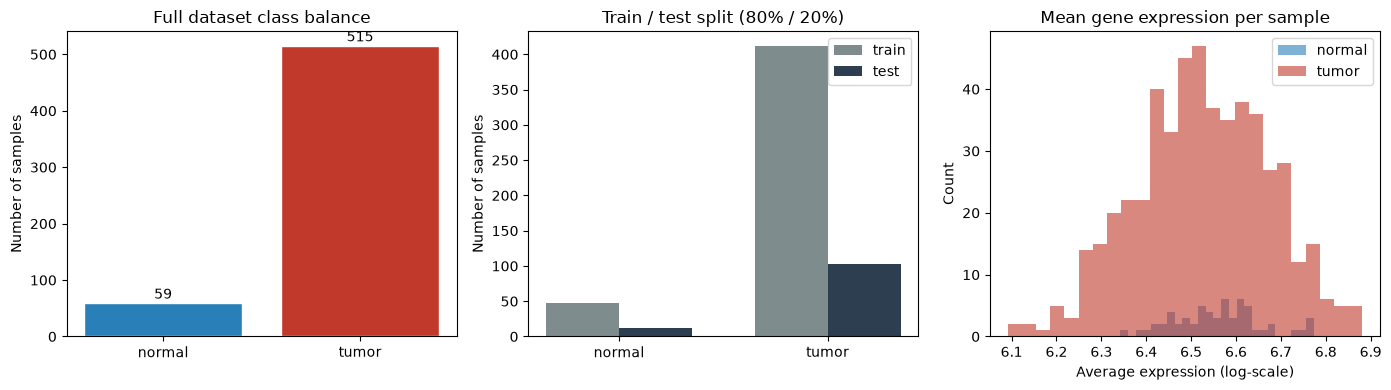

In [55]:
import matplotlib.pyplot as plt

TUMOR_COLOR = "#c0392b"
NORMAL_COLOR = "#2980b9"

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Class balance in full dataset
counts = labels["sample_type"].value_counts().reindex(["normal", "tumor"])
axes[0].bar(counts.index, counts.values, color=[NORMAL_COLOR, TUMOR_COLOR], edgecolor="white")
axes[0].set_title("Full dataset class balance")
axes[0].set_ylabel("Number of samples")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 8, str(v), ha="center")

# 2) Train vs test split (same proportions via stratify)
split_df = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
}).rename(index={0.0: "normal", 1.0: "tumor"})
x = np.arange(len(split_df))
width = 0.35
axes[1].bar(x - width / 2, split_df["train"], width, label="train", color="#7f8c8d")
axes[1].bar(x + width / 2, split_df["test"], width, label="test", color="#2c3e50")
axes[1].set_xticks(x)
axes[1].set_xticklabels(split_df.index)
axes[1].set_title("Train / test split (80% / 20%)")
axes[1].set_ylabel("Number of samples")
axes[1].legend()

# 3) Mean expression per sample by class (raw, unscaled)
sample_means = X.mean(axis=1)
plot_df = pd.DataFrame({
    "mean_expression": sample_means.values,
    "sample_type": labels["sample_type"].values,
})
for sample_type, color in [("normal", NORMAL_COLOR), ("tumor", TUMOR_COLOR)]:
    subset = plot_df.loc[plot_df["sample_type"] == sample_type, "mean_expression"]
    axes[2].hist(subset, bins=25, alpha=0.6, label=sample_type, color=color)
axes[2].set_title("Mean gene expression per sample")
axes[2].set_xlabel("Average expression (log-scale)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

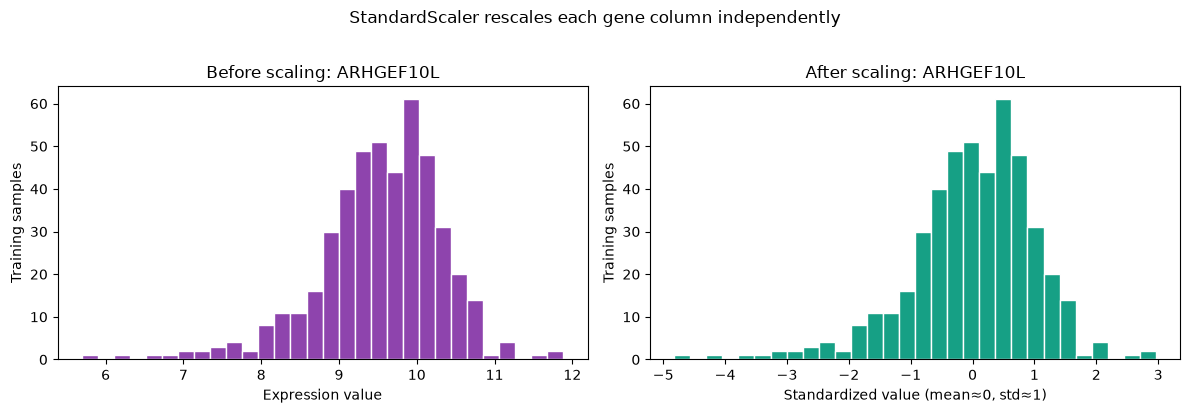

In [56]:
# Before vs after StandardScaler for one example gene
example_gene = X_train.columns[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gene_idx = X_train.columns.get_loc(example_gene)
raw_values = X_train[example_gene]
scaled_values = X_train_scaled[:, gene_idx]

axes[0].hist(raw_values, bins=30, color="#8e44ad", edgecolor="white")
axes[0].set_title(f"Before scaling: {example_gene}")
axes[0].set_xlabel("Expression value")
axes[0].set_ylabel("Training samples")

axes[1].hist(scaled_values, bins=30, color="#16a085", edgecolor="white")
axes[1].set_title(f"After scaling: {example_gene}")
axes[1].set_xlabel("Standardized value (mean≈0, std≈1)")
axes[1].set_ylabel("Training samples")

plt.suptitle("StandardScaler rescales each gene column independently", y=1.02)
plt.tight_layout()
plt.show()

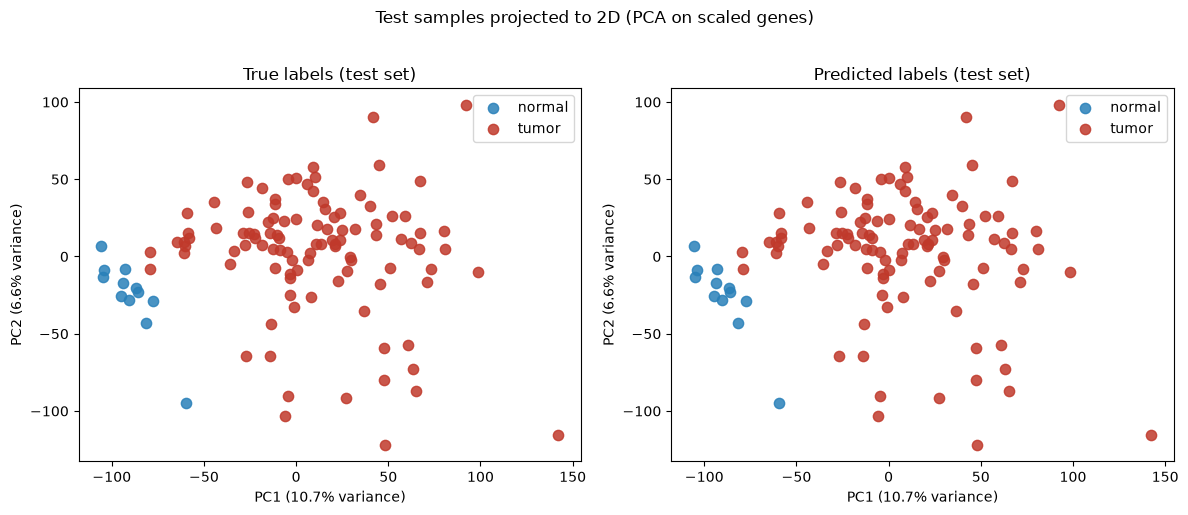

In [57]:
# PCA on scaled test samples: 20,530 genes -> 2 dimensions for plotting
pca = PCA(n_components=2, random_state=42)
test_2d = pca.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, values, title in [
    (axes[0], y_test, "True labels (test set)"),
    (axes[1], y_pred, "Predicted labels (test set)"),
]:
    normal_mask = values == 0
    tumor_mask = values == 1
    ax.scatter(test_2d[normal_mask, 0], test_2d[normal_mask, 1], s=55, alpha=0.85, label="normal", c=NORMAL_COLOR)
    ax.scatter(test_2d[tumor_mask, 0], test_2d[tumor_mask, 1], s=55, alpha=0.85, label="tumor", c=TUMOR_COLOR)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
    ax.legend()

plt.suptitle("Test samples projected to 2D (PCA on scaled genes)", y=1.02)
plt.tight_layout()
plt.show()

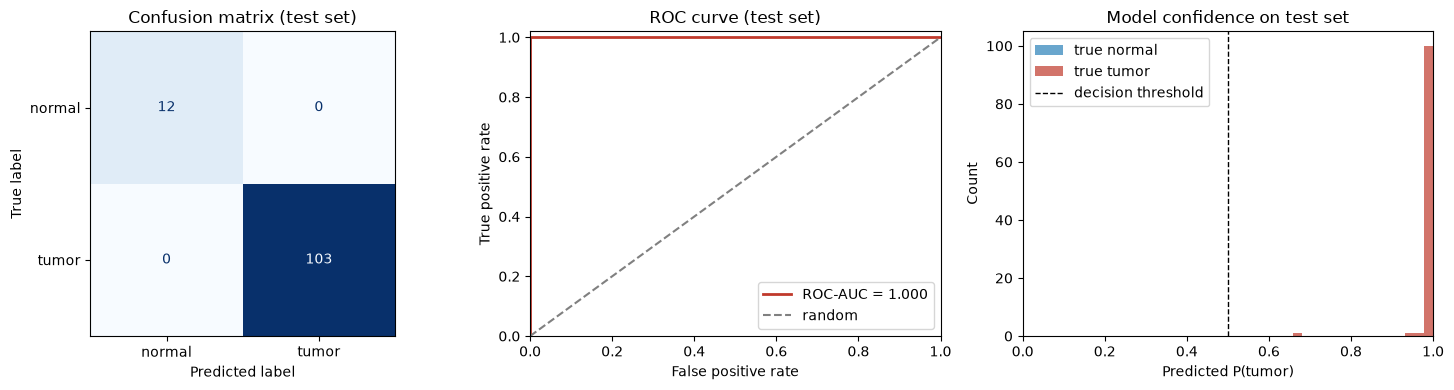

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["normal", "tumor"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix (test set)")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color=TUMOR_COLOR, lw=2, label=f"ROC-AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="random")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve (test set)")
axes[1].legend(loc="lower right")

# Predicted tumor probability by true class
axes[2].hist(y_prob[y_test == 0], bins=15, alpha=0.7, label="true normal", color=NORMAL_COLOR)
axes[2].hist(y_prob[y_test == 1], bins=15, alpha=0.7, label="true tumor", color=TUMOR_COLOR)
axes[2].axvline(0.5, color="black", linestyle="--", linewidth=1, label="decision threshold")
axes[2].set_xlim(0, 1)
axes[2].set_xlabel("Predicted P(tumor)")
axes[2].set_ylabel("Count")
axes[2].set_title("Model confidence on test set")
axes[2].legend()

plt.tight_layout()
plt.show()

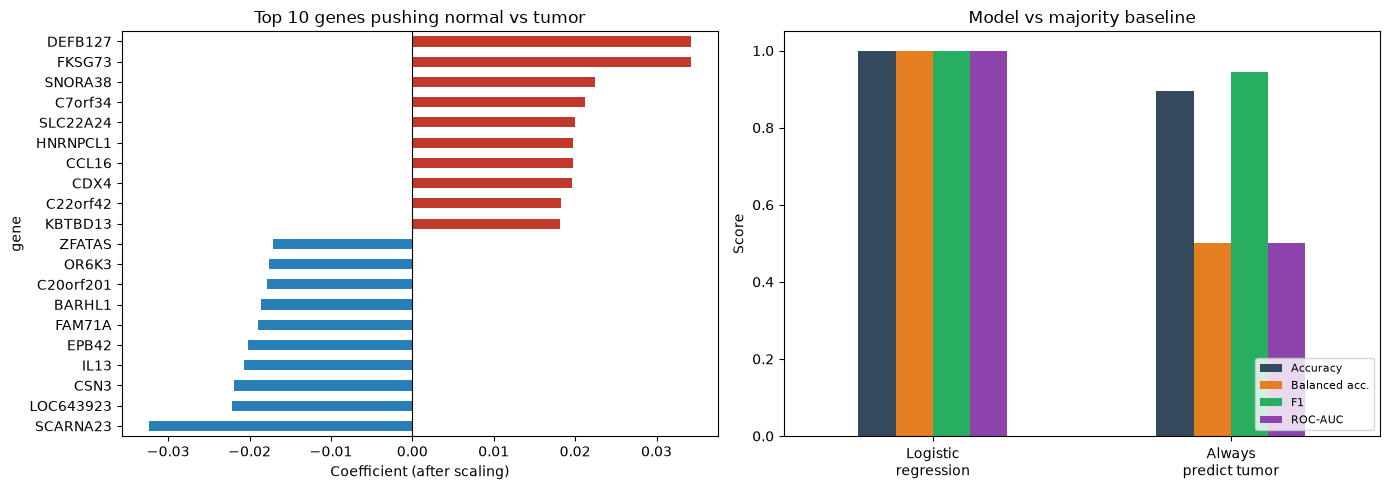

In [59]:
# Top genes the model uses + baseline comparison
coef = pd.Series(model.coef_[0], index=X_train.columns)
top_n = 10

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genes pushing toward tumor vs normal
top_tumor = coef.nlargest(top_n).iloc[::-1]
top_normal = coef.nsmallest(top_n)
combined = pd.concat([top_normal, top_tumor])
colors = [NORMAL_COLOR if v < 0 else TUMOR_COLOR for v in combined.values]
combined.plot.barh(ax=axes[0], color=colors)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title(f"Top {top_n} genes pushing normal vs tumor")
axes[0].set_xlabel("Coefficient (after scaling)")

# Compare model to simple baselines
majority_pred = np.ones_like(y_test)
baseline_scores = {
    "Logistic\nregression": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced acc.": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    },
    "Always\npredict tumor": {
        "Accuracy": accuracy_score(y_test, majority_pred),
        "Balanced acc.": balanced_accuracy_score(y_test, majority_pred),
        "F1": f1_score(y_test, majority_pred),
        "ROC-AUC": roc_auc_score(y_test, np.full_like(y_prob, y_train.mean())),
    },
}
score_df = pd.DataFrame(baseline_scores).T
score_df.plot.bar(ax=axes[1], rot=0, color=["#34495e", "#e67e22", "#27ae60", "#8e44ad"])
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Model vs majority baseline")
axes[1].set_ylabel("Score")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## Sanity checks

In [60]:
(X.index == labels["sample_id"]).all()

np.True_

In [61]:
labels.head()

,sample_id,sample_type,label
0,TCGA-69-7978-01,tumor,1.0
1,TCGA-62-8399-01,tumor,1.0
2,TCGA-78-7539-01,tumor,1.0
3,TCGA-50-5931-11,normal,0.0
4,TCGA-73-4658-01,tumor,1.0


In [62]:
X.head()

gene,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
TCGA-69-7978-01,9.9898,4.2598,0.4181,10.3657,11.1718,10.5897,12.2708,4.7670,0.0000,8.2023,...,1.8836,0.7420,6.2348,0.0000,9.4520,12.7565,8.2668,11.2400,6.1209,9.8977
TCGA-62-8399-01,10.4257,11.6239,0.0000,11.5489,11.0200,9.2843,12.1540,5.7125,0.4628,5.5819,...,0.4628,1.5316,4.4464,1.3294,9.5226,12.2100,8.5437,10.3491,8.6398,9.7315
TCGA-78-7539-01,9.6264,9.1362,1.1231,11.6692,10.4679,10.4649,12.6559,4.3943,0.3725,3.5365,...,2.9588,0.0000,6.0400,3.9201,9.2765,10.6498,6.1814,11.1659,6.0970,10.3540
TCGA-50-5931-11,8.6835,9.4824,0.8221,11.7341,11.6787,11.5412,11.9285,5.9466,0.8221,3.3528,...,0.0000,2.4876,6.3782,0.0000,8.6781,14.6956,9.7151,10.5910,9.5115,10.4914
TCGA-73-4658-01,9.2078,5.0288,0.0000,11.6209,11.3414,10.9376,12.0539,6.0942,0.0000,7.4156,...,0.0000,0.6557,6.3898,1.1048,9.2697,13.0036,8.9786,10.6777,8.4187,10.3142


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, confusion_matrix

y_shuffled = y.sample(frac=1.0, random_state=123).reset_index(drop=True)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_values,
    y_shuffled,
    test_size=0.2,
    random_state=42,
    stratify=y_shuffled,
)

scaler_s = StandardScaler()

X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

model_s = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42,
)

model_s.fit(X_train_s_scaled, y_train_s)

y_pred_s = model_s.predict(X_test_s_scaled)
y_prob_s = model_s.predict_proba(X_test_s_scaled)[:, 1]

print("Shuffled-label accuracy:", accuracy_score(y_test_s, y_pred_s))
print("Shuffled-label balanced accuracy:", balanced_accuracy_score(y_test_s, y_pred_s))
print("Shuffled-label F1:", f1_score(y_test_s, y_pred_s))
print("Shuffled-label ROC-AUC:", roc_auc_score(y_test_s, y_prob_s))
print("\nConfusion matrix:")
print(confusion_matrix(y_test_s, y_pred_s))

Shuffled-label accuracy: 0.8869565217391304
Shuffled-label balanced accuracy: 0.49514563106796117
Shuffled-label F1: 0.9400921658986175
Shuffled-label ROC-AUC: 0.6270226537216829

Confusion matrix:
[[  0  12]
 [  1 102]]


In [64]:
majority_pred = np.ones_like(y_test)

print("Majority accuracy:", accuracy_score(y_test, majority_pred))
print("Majority balanced accuracy:", balanced_accuracy_score(y_test, majority_pred))
print("Majority F1:", f1_score(y_test, majority_pred))
print(confusion_matrix(y_test, majority_pred))

Majority accuracy: 0.8956521739130435
Majority balanced accuracy: 0.5
Majority F1: 0.944954128440367
[[  0  12]
 [  0 103]]
